Wrote 211 excitation evolution rows:
/exp/e961/data/MDsims-data/pnichols/Master_CSVs_v3/excitation_evolved_master.csv
/home/pnichols/MDsims/excitation_evolved_master.csv


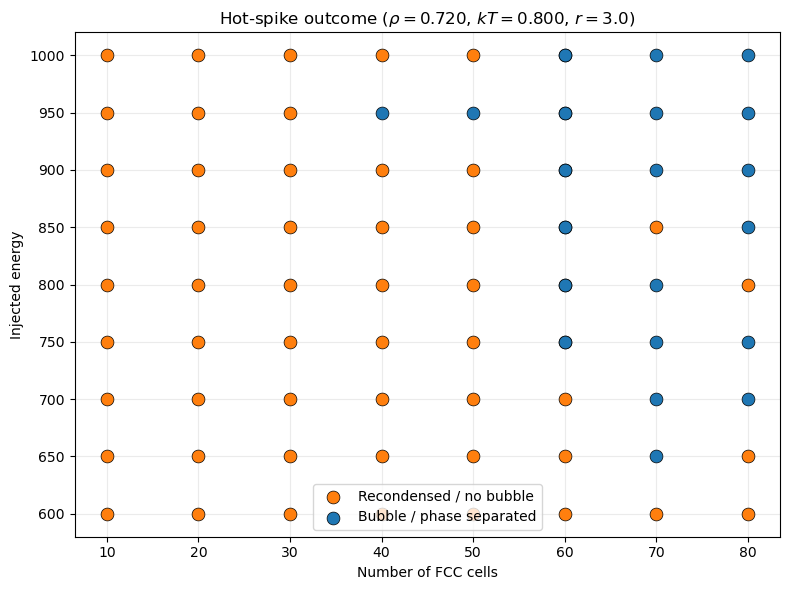

In [1]:
densities = [0.720]
temperatures = [0.800]
energies = [600, 650, 700, 750, 800, 850, 900, 950, 1000]

radii = [3.0]
n_cells = [10, 20, 30, 40, 50, 60, 70, 80]


import matplotlib.pyplot as plt
from md_Helpers import master_csv

# Reads existing run metadata; it does not rerun the simulations.
df = master_csv.build_excitation_evolved_master_csv(include_legacy=False)

sweep = df[
    df["n_fcc_cells"].isin(n_cells)
    & df["energy_deposition"].isin(energies)
    & df["density"].isin(densities)
    & df["temp"].isin(temperatures)
    & df["radius"].isin(radii)
    & (df["excitation_method"] == "velocity_rescale_com")
    & (df["ensemble"].str.upper() == "NVE")
].copy()

colors = {
    "phase_separated": "tab:blue",
    "not_phase_separated": "tab:orange",
}

labels = {
    "phase_separated": "Bubble / phase separated",
    "not_phase_separated": "Recondensed / no bubble",
}

fig, ax = plt.subplots(figsize=(8, 6))

for phase, group in sweep.groupby("voxel_phase"):
    ax.scatter(
        group["n_fcc_cells"],
        group["energy_deposition"],
        s=85,
        color=colors.get(phase, "gray"),
        label=labels.get(phase, phase),
        edgecolor="black",
        linewidth=0.5,
        zorder=3,
    )

ax.set(
    xlabel="Number of FCC cells",
    ylabel="Injected energy",
    title=r"Hot-spike outcome ($\rho=0.720$, $kT=0.800$, $r=3.0$)",
)

ax.set_xticks(n_cells)
ax.set_yticks(energies)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

Wrote 925 excitation evolution rows:
/exp/e961/data/MDsims-data/pnichols/Master_CSVs_v3/excitation_evolved_master.csv
/home/pnichols/MDsims/excitation_evolved_master.csv


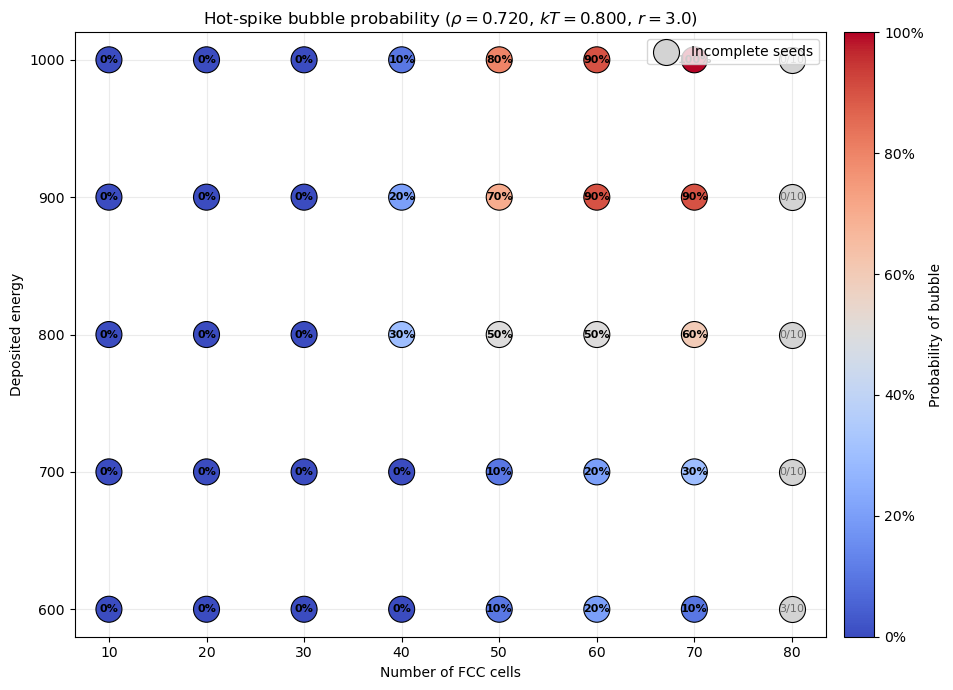

,n_fcc_cells,energy_deposition,n_finished,all_finished,bubble_probability
0,10,600,10,True,0.0
1,10,700,10,True,0.0
2,10,800,10,True,0.0
3,10,900,10,True,0.0
4,10,1000,10,True,0.0
5,20,600,10,True,0.0
6,20,700,10,True,0.0
7,20,800,10,True,0.0
8,20,900,10,True,0.0
9,20,1000,10,True,0.0


In [1]:
densities = [0.720]
temperatures = [0.800]
energies = [600, 700, 800, 900, 1000]

radii = [3.0]
n_cells = [10, 20, 30, 40, 50, 60, 70, 80]
location_seeds = [1,2,3,4,5,6, 7, 8, 9, 10]


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from md_Helpers import master_csv


# ------------------------------------------------------------
# Load and select this sweep
# ------------------------------------------------------------
df = master_csv.build_excitation_evolved_master_csv(
    include_legacy=False
)

sweep = df[
    df["n_fcc_cells"].isin(n_cells)
    & df["energy_deposition"].isin(energies)
    & df["density"].isin(densities)
    & df["temp"].isin(temperatures)
    & df["radius"].isin(radii)
    & df["excitation_method"].eq("velocity_rescale_com")
    & df["ensemble"].fillna("NVE").str.upper().eq("NVE")
    & df["source_nsteps"].eq(1_000_000)
    & df["source_seed"].eq(1)
    & df["evolve_seed"].eq(1)
    & df["nsteps2"].eq(980_000)
    & np.isclose(df["dt2"], 0.005)
].copy()


# location_seed is encoded in the run directory
sweep["location_seed"] = pd.to_numeric(
    sweep["run_path"].str.extract(
        r"random_center_seed_(\d+)", expand=False
    ),
    errors="coerce",
)

sweep = sweep[
    sweep["location_seed"].isin(location_seeds)
].copy()

sweep["location_seed"] = sweep["location_seed"].astype(int)


# If duplicate summaries exist for a seed, keep the newest one
sweep = (
    sweep.sort_values("last_updated")
    .drop_duplicates(
        ["n_fcc_cells", "energy_deposition", "location_seed"],
        keep="last",
    )
)


# ------------------------------------------------------------
# Determine which seeds have finished
# ------------------------------------------------------------

# A normal run is finished when all output files exist.
normal_finish = sweep["files_complete"].fillna(False).eq(True)

# A terminal bubble stop is also a completed, classified outcome.
terminal_bubble = (
    sweep["terminal"].fillna(False).eq(True)
    & sweep["outcome"].fillna("").eq("bubble")
)

sweep["finished"] = normal_finish | terminal_bubble

# Bubble classification: explicit terminal bubble or final phase separation
sweep["bubble"] = (
    sweep["outcome"].fillna("").eq("bubble")
    | sweep["voxel_phase"].fillna("").eq("phase_separated")
)


# ------------------------------------------------------------
# Build the full grid, including combinations with no results
# ------------------------------------------------------------
expected_seeds = set(location_seeds)
records = []

for n_cell in n_cells:
    for energy in energies:
        point = sweep[
            sweep["n_fcc_cells"].eq(n_cell)
            & sweep["energy_deposition"].eq(energy)
        ]

        finished = point[point["finished"]]
        finished_seeds = set(finished["location_seed"])

        all_finished = expected_seeds.issubset(finished_seeds)
        n_finished = len(expected_seeds & finished_seeds)

        bubble_probability = (
            finished["bubble"].mean()
            if all_finished
            else np.nan
        )

        records.append({
            "n_fcc_cells": n_cell,
            "energy_deposition": energy,
            "n_finished": n_finished,
            "all_finished": all_finished,
            "bubble_probability": bubble_probability,
        })

summary = pd.DataFrame(records)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
complete = summary[summary["all_finished"]]
incomplete = summary[~summary["all_finished"]]

fig, ax = plt.subplots(figsize=(10, 7))

probability_points = ax.scatter(
    complete["n_fcc_cells"],
    complete["energy_deposition"],
    c=complete["bubble_probability"],
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    s=350,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
)

ax.scatter(
    incomplete["n_fcc_cells"],
    incomplete["energy_deposition"],
    color="lightgray",
    s=350,
    edgecolor="black",
    linewidth=0.8,
    label="Incomplete seeds",
    zorder=3,
)

# Annotate complete points with probability and incomplete points with seed count
for row in complete.itertuples():
    ax.annotate(
        f"{row.bubble_probability:.0%}",
        (row.n_fcc_cells, row.energy_deposition),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
    )

for row in incomplete.itertuples():
    ax.annotate(
        f"{row.n_finished}/{len(location_seeds)}",
        (row.n_fcc_cells, row.energy_deposition),
        ha="center",
        va="center",
        fontsize=8,
        color="dimgray",
    )

colorbar = fig.colorbar(probability_points, ax=ax, pad=0.02)
colorbar.set_label("Probability of bubble")
colorbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set(
    xlabel="Number of FCC cells",
    ylabel="Deposited energy",
    title=(
        r"Hot-spike bubble probability "
        r"($\rho=0.720$, $kT=0.800$, $r=3.0$)"
    ),
)

ax.set_xticks(n_cells)
ax.set_yticks(energies)
ax.grid(alpha=0.25)
ax.legend(loc="best")

fig.tight_layout()
plt.show()

display(
    summary.sort_values(
        ["n_fcc_cells", "energy_deposition"]
    ).reset_index(drop=True)
)

Wrote 803 excitation evolution rows:
/exp/e961/data/MDsims-data/pnichols/Master_CSVs_v3/excitation_evolved_master.csv
/home/pnichols/MDsims/excitation_evolved_master.csv


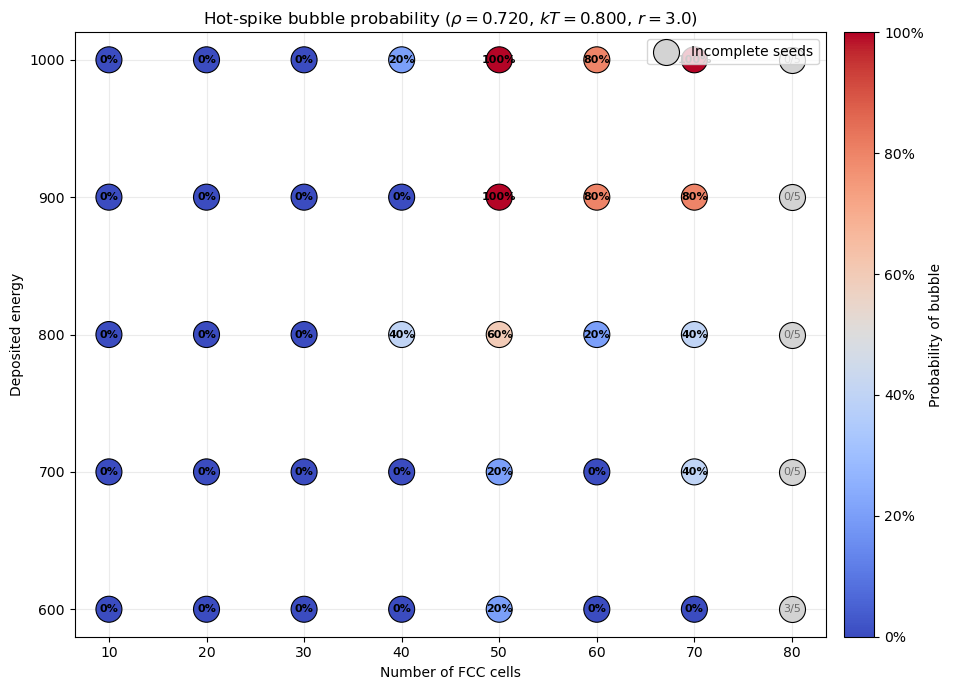

,n_fcc_cells,energy_deposition,n_finished,all_finished,bubble_probability
0,10,600,5,True,0.0
1,10,700,5,True,0.0
2,10,800,5,True,0.0
3,10,900,5,True,0.0
4,10,1000,5,True,0.0
5,20,600,5,True,0.0
6,20,700,5,True,0.0
7,20,800,5,True,0.0
8,20,900,5,True,0.0
9,20,1000,5,True,0.0


In [9]:
densities = [0.720]
temperatures = [0.800]
energies = [600, 700, 800, 900, 1000]

radii = [3.0]
n_cells = [10, 20, 30, 40, 50, 60, 70, 80]
location_seeds = [6, 7, 8, 9, 10]


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from md_Helpers import master_csv


# ------------------------------------------------------------
# Load and select this sweep
# ------------------------------------------------------------
df = master_csv.build_excitation_evolved_master_csv(
    include_legacy=False
)

sweep = df[
    df["n_fcc_cells"].isin(n_cells)
    & df["energy_deposition"].isin(energies)
    & df["density"].isin(densities)
    & df["temp"].isin(temperatures)
    & df["radius"].isin(radii)
    & df["excitation_method"].eq("velocity_rescale_com")
    & df["ensemble"].fillna("NVE").str.upper().eq("NVE")
    & df["source_nsteps"].eq(1_000_000)
    & df["source_seed"].eq(1)
    & df["evolve_seed"].eq(1)
    & df["nsteps2"].eq(980_000)
    & np.isclose(df["dt2"], 0.005)
].copy()


# location_seed is encoded in the run directory
sweep["location_seed"] = pd.to_numeric(
    sweep["run_path"].str.extract(
        r"random_center_seed_(\d+)", expand=False
    ),
    errors="coerce",
)

sweep = sweep[
    sweep["location_seed"].isin(location_seeds)
].copy()

sweep["location_seed"] = sweep["location_seed"].astype(int)


# If duplicate summaries exist for a seed, keep the newest one
sweep = (
    sweep.sort_values("last_updated")
    .drop_duplicates(
        ["n_fcc_cells", "energy_deposition", "location_seed"],
        keep="last",
    )
)


# ------------------------------------------------------------
# Determine which seeds have finished
# ------------------------------------------------------------

# A normal run is finished when all output files exist.
normal_finish = sweep["files_complete"].fillna(False).eq(True)

# A terminal bubble stop is also a completed, classified outcome.
terminal_bubble = (
    sweep["terminal"].fillna(False).eq(True)
    & sweep["outcome"].fillna("").eq("bubble")
)

sweep["finished"] = normal_finish | terminal_bubble

# Bubble classification: explicit terminal bubble or final phase separation
sweep["bubble"] = (
    sweep["outcome"].fillna("").eq("bubble")
    | sweep["voxel_phase"].fillna("").eq("phase_separated")
)


# ------------------------------------------------------------
# Build the full grid, including combinations with no results
# ------------------------------------------------------------
expected_seeds = set(location_seeds)
records = []

for n_cell in n_cells:
    for energy in energies:
        point = sweep[
            sweep["n_fcc_cells"].eq(n_cell)
            & sweep["energy_deposition"].eq(energy)
        ]

        finished = point[point["finished"]]
        finished_seeds = set(finished["location_seed"])

        all_finished = expected_seeds.issubset(finished_seeds)
        n_finished = len(expected_seeds & finished_seeds)

        bubble_probability = (
            finished["bubble"].mean()
            if all_finished
            else np.nan
        )

        records.append({
            "n_fcc_cells": n_cell,
            "energy_deposition": energy,
            "n_finished": n_finished,
            "all_finished": all_finished,
            "bubble_probability": bubble_probability,
        })

summary = pd.DataFrame(records)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
complete = summary[summary["all_finished"]]
incomplete = summary[~summary["all_finished"]]

fig, ax = plt.subplots(figsize=(10, 7))

probability_points = ax.scatter(
    complete["n_fcc_cells"],
    complete["energy_deposition"],
    c=complete["bubble_probability"],
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    s=350,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
)

ax.scatter(
    incomplete["n_fcc_cells"],
    incomplete["energy_deposition"],
    color="lightgray",
    s=350,
    edgecolor="black",
    linewidth=0.8,
    label="Incomplete seeds",
    zorder=3,
)

# Annotate complete points with probability and incomplete points with seed count
for row in complete.itertuples():
    ax.annotate(
        f"{row.bubble_probability:.0%}",
        (row.n_fcc_cells, row.energy_deposition),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
    )

for row in incomplete.itertuples():
    ax.annotate(
        f"{row.n_finished}/{len(location_seeds)}",
        (row.n_fcc_cells, row.energy_deposition),
        ha="center",
        va="center",
        fontsize=8,
        color="dimgray",
    )

colorbar = fig.colorbar(probability_points, ax=ax, pad=0.02)
colorbar.set_label("Probability of bubble")
colorbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set(
    xlabel="Number of FCC cells",
    ylabel="Deposited energy",
    title=(
        r"Hot-spike bubble probability "
        r"($\rho=0.720$, $kT=0.800$, $r=3.0$)"
    ),
)

ax.set_xticks(n_cells)
ax.set_yticks(energies)
ax.grid(alpha=0.25)
ax.legend(loc="best")

fig.tight_layout()
plt.show()

display(
    summary.sort_values(
        ["n_fcc_cells", "energy_deposition"]
    ).reset_index(drop=True)
)